In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("credit_data.csv")
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 279856 entries, 0 to 279855
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       279856 non-null  int64  
 1   Gender                    279856 non-null  str    
 2   Income                    279856 non-null  int64  
 3   Credit Score              279856 non-null  int64  
 4   Credit History Length     279856 non-null  int64  
 5   Number of Existing Loans  279856 non-null  int64  
 6   Loan Amount               279856 non-null  int64  
 7   Loan Tenure               279856 non-null  int64  
 8   Existing Customer         279856 non-null  str    
 9   State                     279856 non-null  str    
 10  City                      279856 non-null  str    
 11  LTV Ratio                 279856 non-null  float64
 12  Employment Profile        279856 non-null  str    
 13  Profile Score             279856 non-null  int64  
 14 

(279856, 15)

In [35]:
df.describe()

,Age,Income,Credit Score,Credit History Length,Number of Existing Loans,Loan Amount,Loan Tenure,LTV Ratio,Profile Score
count,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000
mean,44.005217,76499.163856,582.953773,307.965146,4.701693,105795.342773,133.340654,71.643101,77.350155
std,15.311051,42875.575193,163.076754,175.083268,2.980351,40458.370929,96.064132,16.865785,24.509196
min,18.000000,9000.000000,300.000000,6.000000,0.000000,5294.000000,12.000000,40.000000,0.000000
25%,31.000000,42000.000000,446.000000,156.000000,2.000000,72173.000000,62.000000,58.105848,61.000000
50%,44.000000,68000.000000,584.000000,307.000000,5.000000,111263.000000,100.000000,72.133017,89.000000
75%,57.000000,104000.000000,722.000000,460.000000,7.000000,150000.000000,201.000000,86.239725,98.000000
max,70.000000,209000.000000,850.000000,611.000000,10.000000,150000.000000,359.000000,95.000000,100.000000


In [36]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\nUnique values in {col}: {df[col].nunique()}")


Unique values in Gender: 3

Unique values in Existing Customer: 2

Unique values in State: 10

Unique values in City: 23

Unique values in Employment Profile: 5

Unique values in Occupation: 14


C:\Users\user\AppData\Local\Temp\ipykernel_21680\1173995108.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


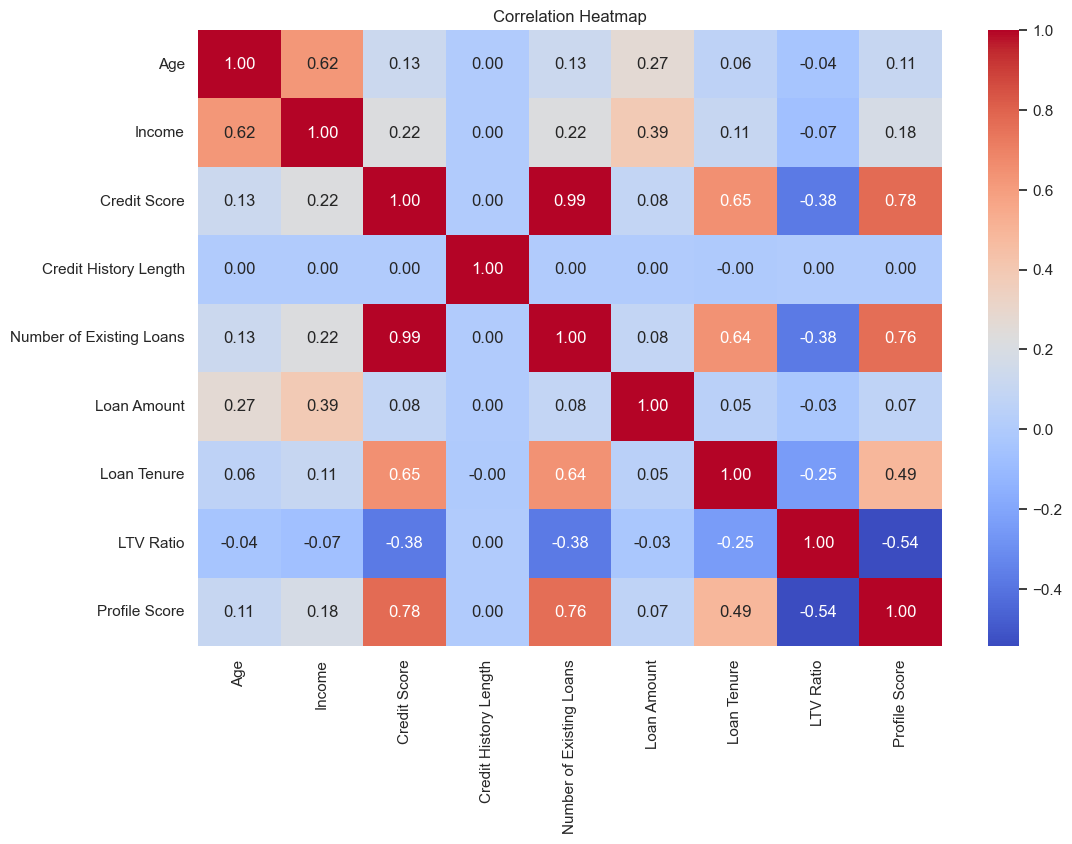

In [37]:
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Removing Values
1 Since Credit history Lenght has no correlation with any variable and its not constant, we should rather remove it

2 Notice Number of existing Loans and Credit score are almost similar in correlation to everything and have a 0.99 correlation, so we drop Number of exisiting Loans

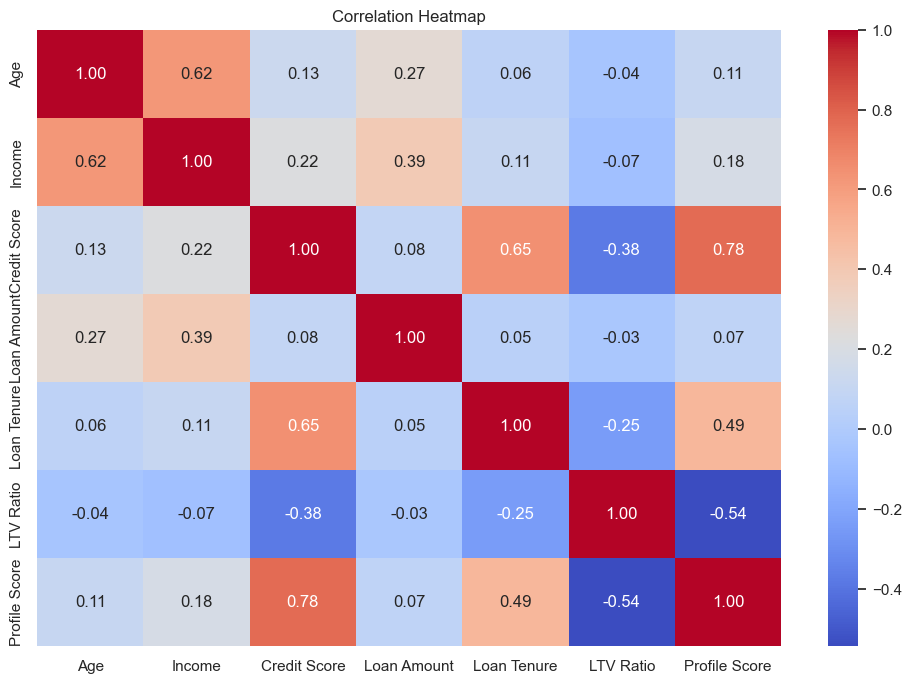

In [38]:
df = df.drop(columns=["Number of Existing Loans", "Credit History Length"])

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Resolving Missing Data
Since 6.53% rows dont have "Occupation", we introduce "Unknown" as their occupation
### Reasons
- Training a mini-classifier is too much compuation for this task
- No-Data probably represnts Unemployed or Informal Sector jobs
- The final model may learn correlation of "Unknown" with Credit Risk

In [39]:
print(df['Occupation'].isnull().sum())
df['Occupation'] = df['Occupation'].fillna('Unknown')
print(df['Occupation'].isnull().sum())

18272
0


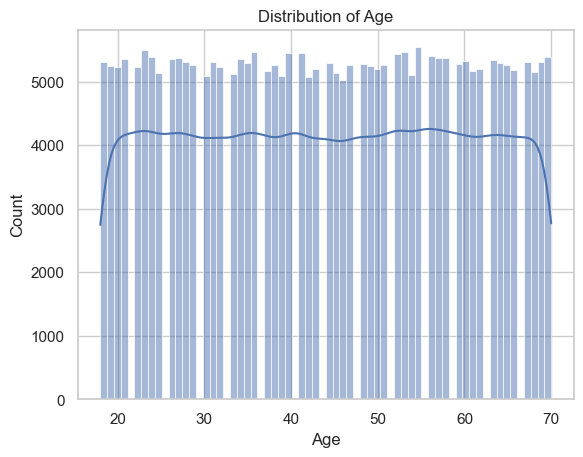

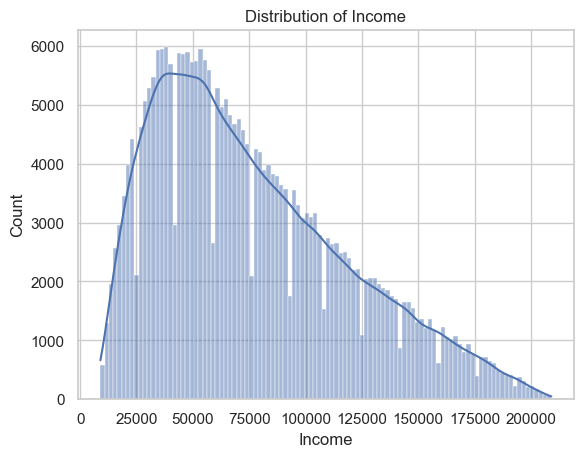

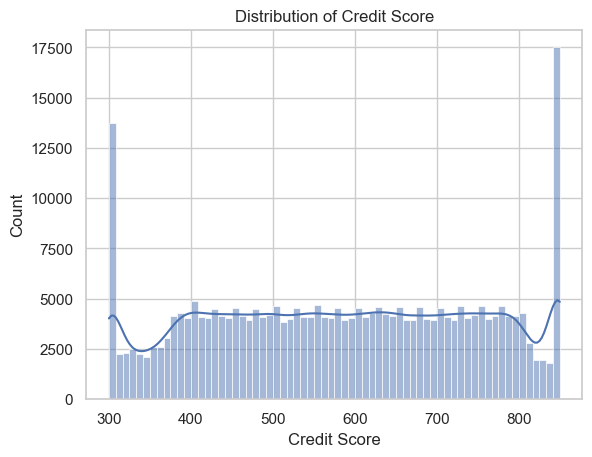

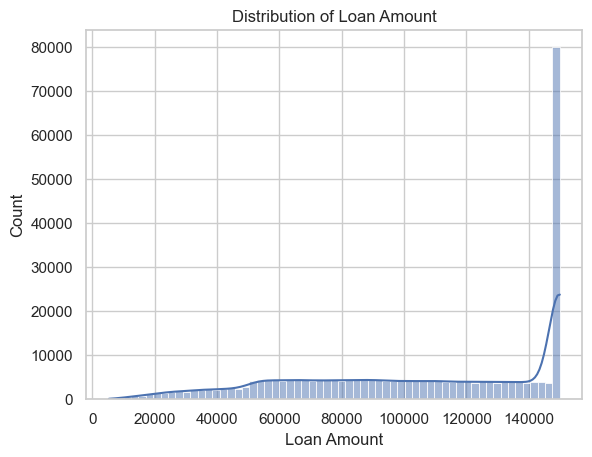

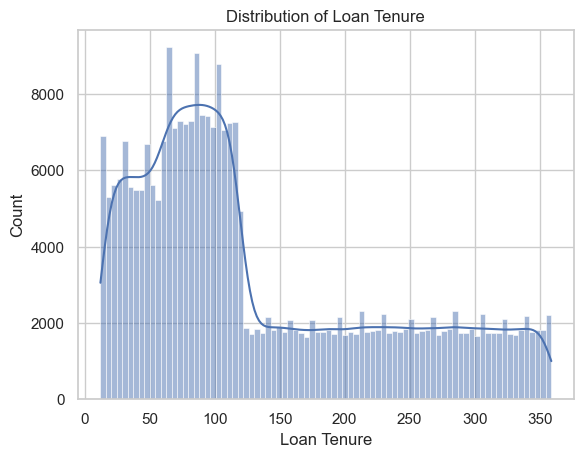

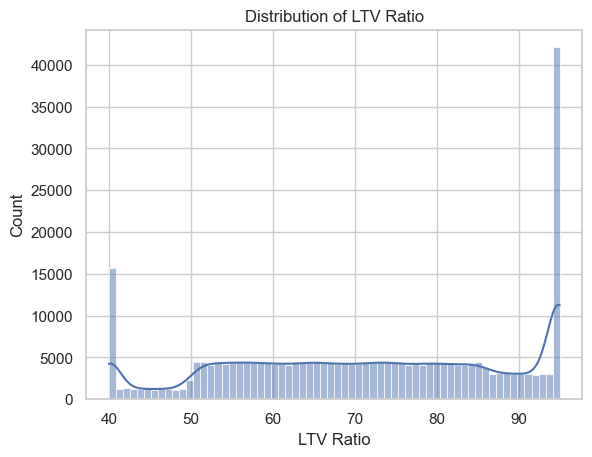

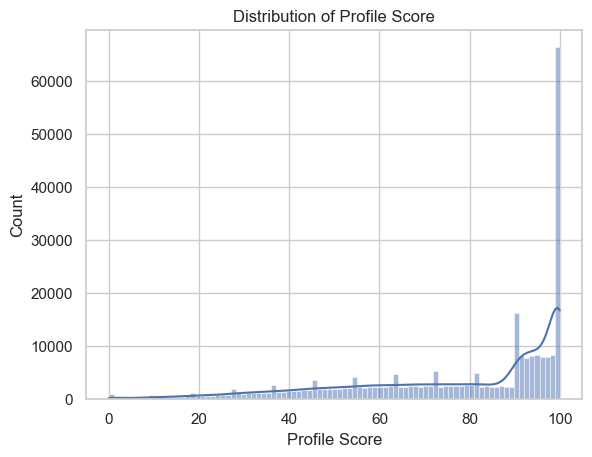

In [40]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [41]:
for col in num_cols:
    col_min = df[col].min()
    col_max = df[col].max()
        
    min_count = (df[col] == col_min).sum()
    max_count = (df[col] == col_max).sum()
        
    min_pct = (min_count / len(df)) * 100
    max_pct = (max_count / len(df)) * 100

    print(f"{col}, MinSpike = {min_pct:.2f}% and MaxSpike = {max_pct:.2f}%")

Age, MinSpike = 1.90% and MaxSpike = 1.93%
Income, MinSpike = 0.06% and MaxSpike = 0.01%
Credit Score, MinSpike = 4.06% and MaxSpike = 5.58%
Loan Amount, MinSpike = 0.00% and MaxSpike = 27.17%
Loan Tenure, MinSpike = 0.53% and MaxSpike = 0.16%
LTV Ratio, MinSpike = 5.14% and MaxSpike = 13.93%
Profile Score, MinSpike = 0.31% and MaxSpike = 20.90%


In [42]:
df['Is_Max_Loan'] = (df['Loan Amount'] == df['Loan Amount'].max()).astype(int)
df['Is_Max_Profile'] = (df['Profile Score'] == df['Profile Score'].max()).astype(int)
df['Is_Max_LTV'] = (df['LTV Ratio'] == df['LTV Ratio'].max()).astype(int)

sns.set_theme(style="whitegrid")

<Figure size 1200x600 with 0 Axes>

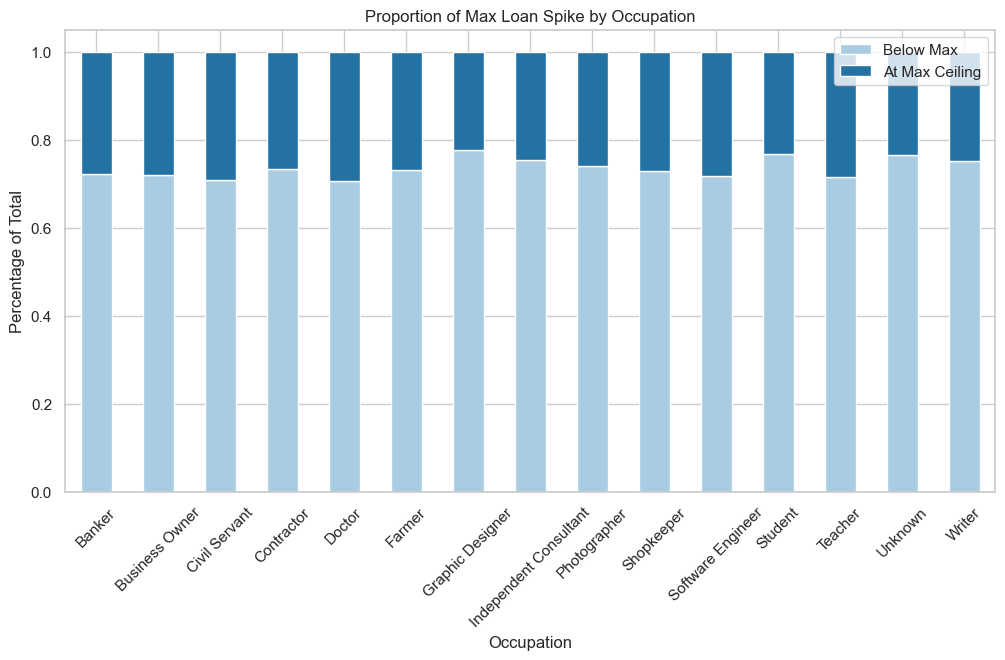

In [43]:
plt.figure(figsize=(12, 6))
pivot_df = df.groupby(['Occupation', 'Is_Max_Loan']).size().unstack()
pivot_df_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0)

pivot_df_pct.plot(kind='bar', stacked=True, color=['#A9CCE3', '#2471A3'], figsize=(12,6))
plt.title('Proportion of Max Loan Spike by Occupation')
plt.ylabel('Percentage of Total')
plt.legend(['Below Max', 'At Max Ceiling'], loc='upper right')
plt.xticks(rotation=45)
plt.show()

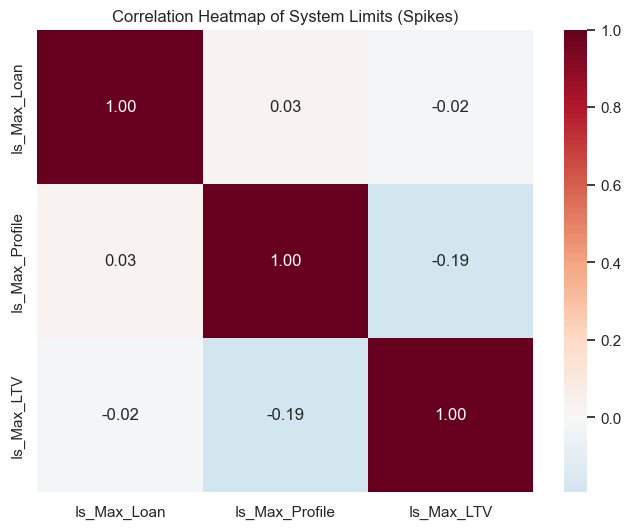

In [44]:
plt.figure(figsize=(8, 6))
spike_corr = df[['Is_Max_Loan', 'Is_Max_Profile', 'Is_Max_LTV']].corr()

sns.heatmap(spike_corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap of System Limits (Spikes)')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_21680\3811300156.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Is_Max_Loan', y='Income', data=df, inner="quartile", palette="muted")


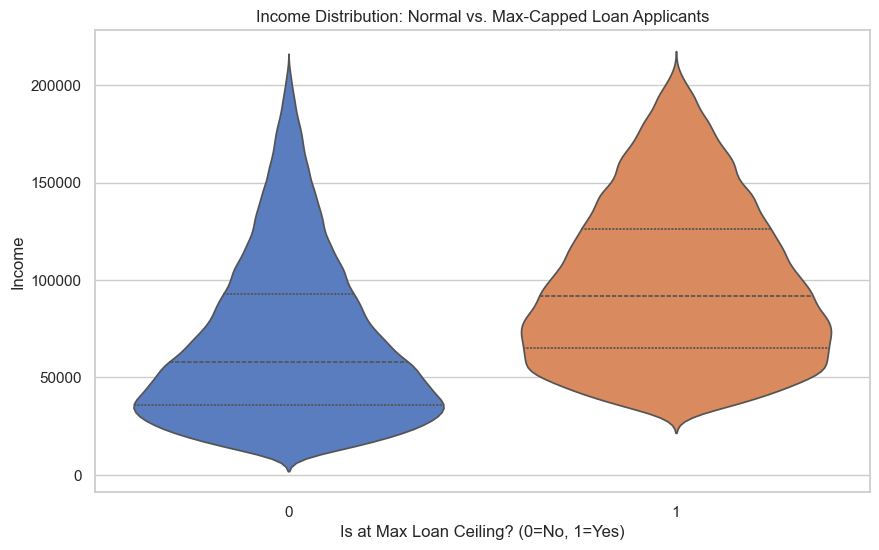

In [45]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Is_Max_Loan', y='Income', data=df, inner="quartile", palette="muted")

plt.title('Income Distribution: Normal vs. Max-Capped Loan Applicants')
plt.xlabel('Is at Max Loan Ceiling? (0=No, 1=Yes)')
plt.ylabel('Income')
plt.show()

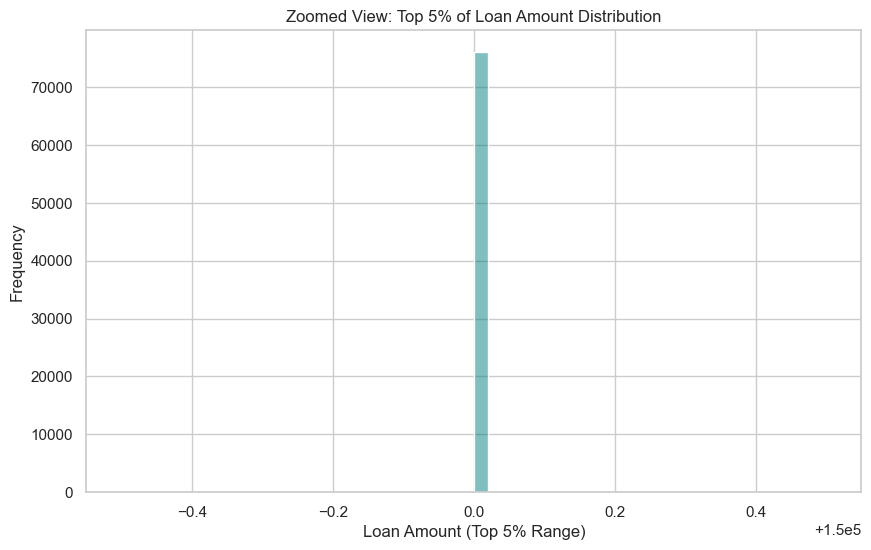

In [46]:
plt.figure(figsize=(10, 6))
threshold = df['Loan Amount'].quantile(0.95)
zoomed_data = df[df['Loan Amount'] >= threshold]

sns.histplot(zoomed_data['Loan Amount'], bins=50, kde=True, color='teal')
plt.title('Zoomed View: Top 5% of Loan Amount Distribution')
plt.xlabel('Loan Amount (Top 5% Range)')
plt.ylabel('Frequency')
plt.show()

# Dealing With Spikes

In [47]:
df['Is_Max_Loan_Amount'] = (df['Loan Amount'] == df['Loan Amount'].max()).astype(int)

df['Is_Max_Profile_Score'] = (df['Profile Score'] == df['Profile Score'].max()).astype(int)

df['Is_Min_LTV'] = (df['LTV Ratio'] == df['LTV Ratio'].min()).astype(int)
df['Is_Max_LTV'] = (df['LTV Ratio'] == df['LTV Ratio'].max()).astype(int)

df['Is_Min_Credit_Score'] = (df['Credit Score'] == df['Credit Score'].min()).astype(int)
df['Is_Max_Credit_Score'] = (df['Credit Score'] == df['Credit Score'].max()).astype(int)

# Scaling

In [48]:
df['Income'] = np.log1p(df['Income'])

df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 279856 entries, 0 to 279855
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Age                   279856 non-null  int64  
 1   Gender                279856 non-null  str    
 2   Income                279856 non-null  float64
 3   Credit Score          279856 non-null  int64  
 4   Loan Amount           279856 non-null  int64  
 5   Loan Tenure           279856 non-null  int64  
 6   Existing Customer     279856 non-null  str    
 7   State                 279856 non-null  str    
 8   City                  279856 non-null  str    
 9   LTV Ratio             279856 non-null  float64
 10  Employment Profile    279856 non-null  str    
 11  Profile Score         279856 non-null  int64  
 12  Occupation            279856 non-null  str    
 13  Is_Max_Loan           279856 non-null  int64  
 14  Is_Max_Profile        279856 non-null  int64  
 15  Is_Max_LTV 

(279856, 21)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

cat_cols = [
    'Gender', 'Existing Customer', 'State', 'City', 
    'Employment Profile', 'Occupation',
    'Is_Max_Loan_Amount', 'Is_Max_Profile_Score', 'Is_Min_LTV', 
    'Is_Max_LTV', 'Is_Min_Credit_Score', 'Is_Max_Credit_Score'
]

cat_idx = [df.columns.get_loc(col) for col in cat_cols]

df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 279856 entries, 0 to 279855
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Age                   279856 non-null  float64
 1   Gender                279856 non-null  str    
 2   Income                279856 non-null  float64
 3   Credit Score          279856 non-null  float64
 4   Loan Amount           279856 non-null  float64
 5   Loan Tenure           279856 non-null  float64
 6   Existing Customer     279856 non-null  str    
 7   State                 279856 non-null  str    
 8   City                  279856 non-null  str    
 9   LTV Ratio             279856 non-null  float64
 10  Employment Profile    279856 non-null  str    
 11  Profile Score         279856 non-null  float64
 12  Occupation            279856 non-null  str    
 13  Is_Max_Loan           279856 non-null  int64  
 14  Is_Max_Profile        279856 non-null  int64  
 15  Is_Max_LTV 

(279856, 21)

In [51]:
df.describe()

,Age,Income,Credit Score,Loan Amount,Loan Tenure,LTV Ratio,Profile Score,Is_Max_Loan,Is_Max_Profile,Is_Max_LTV,Is_Max_Loan_Amount,Is_Max_Profile_Score,Is_Min_LTV,Is_Min_Credit_Score,Is_Max_Credit_Score
count,2.798560e+05,2.798560e+05,2.798560e+05,2.798560e+05,2.798560e+05,2.798560e+05,2.798560e+05,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000
mean,2.031167e-16,2.416276e-15,-5.971630e-17,3.051828e-17,-8.409030e-17,2.809104e-16,2.453649e-16,0.271718,0.209018,0.139325,0.271718,0.209018,0.051412,0.040603,0.055832
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,0.444846,0.406608,0.346286,0.444846,0.406608,0.220837,0.197369,0.229598
min,-1.698464e+00,-3.177057e+00,-1.735099e+00,-2.484072e+00,-1.263124e+00,-1.876175e+00,-3.155970e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.494022e-01,-6.885895e-01,-8.398132e-01,-8.310370e-01,-7.426370e-01,-8.026474e-01,-6.671041e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-3.407329e-04,8.981149e-02,6.415563e-03,1.351430e-01,-3.470672e-01,2.904800e-02,4.753263e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.487207e-01,7.762076e-01,8.526444e-01,1.092598e+00,7.043156e-01,8.654593e-01,8.425361e-01,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.697782e+00,1.903736e+00,1.637552e+00,1.092598e+00,2.349053e+00,1.384871e+00,9.241383e-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [52]:
df.to_csv('final_dataset.csv', index=False)